#  Probabilistic Clustering with Gaussian Mixture Models (GMM)

This notebook applies Gaussian Mixture Models to perform probabilistic customer segmentation.

Unlike K-Means:
- GMM assumes data is generated from a mixture of Gaussian distributions.
- Each customer receives a probability of belonging to each cluster.
- Assignments are soft (probabilistic), not hard.

We focus on the same metric features used in previous clustering steps to ensure consistency.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [3]:

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Feature definitions
behavioral_features = [
    'income', 'frq', 'per_net_purchase', 'spent_online'
]

preference_features = [
    'clothes', 'kitchen', 'small_appliances',
    'toys', 'house_keeping'
]

metric_features = behavioral_features + preference_features

In [2]:
df = pd.read_csv('df_cleaned.csv')

## Gaussian Mixture Model

In [8]:
from sklearn.mixture import GaussianMixture

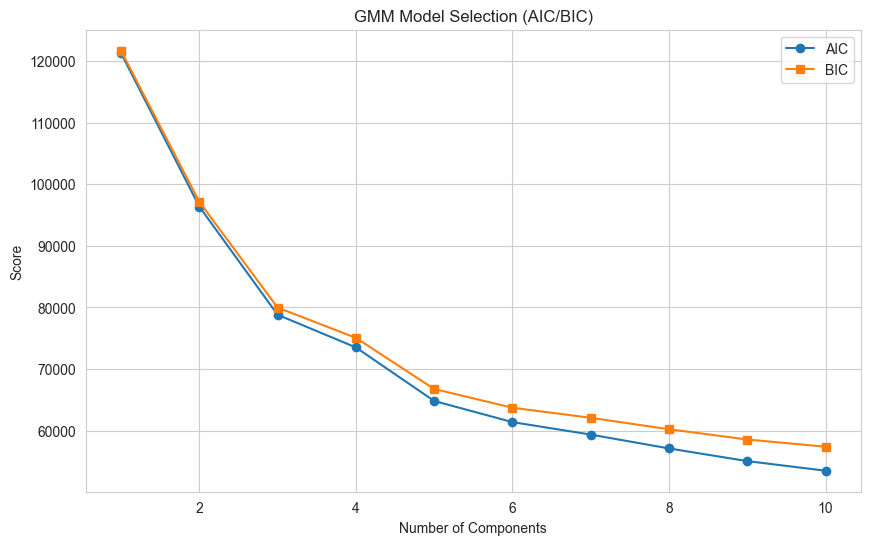

In [7]:
n_components = range(1, 11)
aic_scores = []
bic_scores = []

for n in n_components:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(df[metric_features])
    aic_scores.append(gmm.aic(df[metric_features]))
    bic_scores.append(gmm.bic(df[metric_features]))

plt.plot(n_components, aic_scores, marker='o', label='AIC')
plt.plot(n_components, bic_scores, marker='s', label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("GMM Model Selection (AIC/BIC)")
plt.legend()
plt.show()

##  Model Selection Using AIC & BIC

To determine the optimal number of components, we evaluate:

- **AIC (Akaike Information Criterion)**
- **BIC (Bayesian Information Criterion)**

Lower values indicate better model fit while penalizing model complexity.

The curves suggest an appropriate number of components around:
###  7 clusters

In [9]:
gmm = GaussianMixture(
    n_components=7,
    covariance_type='full',
    n_init=10,
    random_state=42
)

gmm.fit(df[metric_features])

df['gmm_labels'] = gmm.predict(df[metric_features])

probabilities = gmm.predict_proba(df[metric_features])
df['gmm_confidence'] = probabilities.max(axis=1)


In [10]:
df['gmm_confidence'].describe()


count    8948.000000
mean        0.914570
std         0.134022
min         0.295901
25%         0.887936
50%         0.986173
75%         0.999159
max         1.000000
Name: gmm_confidence, dtype: float64

##  Assignment Confidence Analysis

The `gmm_confidence` score represents the maximum probability of cluster membership.

### Observations:
- Mean confidence ≈ 0.91
- Median confidence ≈ 0.99
- Most customers have strong cluster assignments
- Minimum confidence ≈ 0.30

This indicates well-separated probabilistic clusters.

## Probability Distribution Visualization

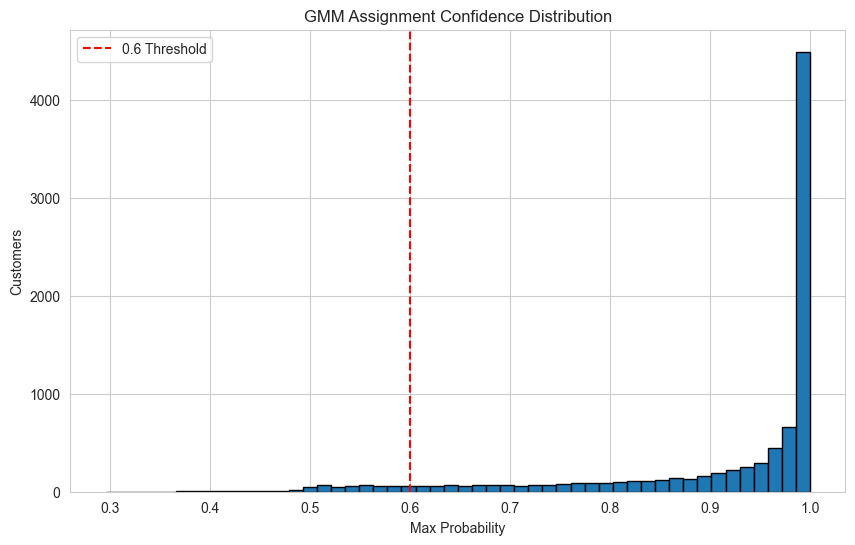

In [12]:
plt.hist(df['gmm_confidence'], bins=50, edgecolor='black')
plt.axvline(0.6, color='red', linestyle='--', label="0.6 Threshold")
plt.title("GMM Assignment Confidence Distribution")
plt.xlabel("Max Probability")
plt.ylabel("Customers")
plt.legend()
plt.show()

In [13]:
threshold = 0.6
low_confidence = df[df['gmm_confidence'] < threshold]

print("Uncertain customers:", len(low_confidence))
print("Percentage:", round(len(low_confidence)/len(df)*100,2), "%")

Uncertain customers: 508
Percentage: 5.68 %


###  Uncertain Customer Segment

Customers with confidence < 0.6:
- Total: 508
- Percentage: 5.68%

These customers:
- Do not strongly belong to a single segment
- Represent hybrid behavioral patterns
- May require flexible marketing strategies

## Profile Uncertain Customers

In [14]:
uncertain_profile = low_confidence[metric_features].mean().round(2)
uncertain_profile

income              0.02
frq                -0.19
per_net_purchase   -0.07
spent_online       -0.16
clothes             0.10
kitchen            -0.16
small_appliances    0.09
toys               -0.15
house_keeping      -0.13
dtype: float64

In [15]:
population_profile = df[metric_features].mean().round(2)

comparison = pd.DataFrame({
    "Population Mean": population_profile,
    "Uncertain Mean": uncertain_profile
})

comparison

,Population Mean,Uncertain Mean
income,0.00,0.02
frq,0.00,-0.19
per_net_purchase,0.00,-0.07
spent_online,-0.00,-0.16
clothes,0.01,0.10
kitchen,-0.01,-0.16
small_appliances,0.00,0.09
toys,-0.01,-0.15
house_keeping,-0.01,-0.13


### Profiling Uncertain Customers

Comparing uncertain customers to the overall population:

Key observations:
- Slightly lower purchase frequency
- Slightly lower online spending
- Moderate product engagement
- Close to population averages overall

Interpretation:
These customers sit near cluster boundaries and may exhibit mixed behaviors.

## Compute R2 for GMM

In [16]:
def get_ss(df, features):
    return np.sum(df[features].var() * (df[features].count() - 1))

def get_ssw(df, features, label_col):
    return df.groupby(label_col)[features].apply(
        lambda x: get_ss(x, features)
    ).sum()

def get_rsq(df, features, label_col):
    sst = get_ss(df, features)
    ssw = get_ssw(df, features, label_col)
    return 1 - (ssw / sst)

r2_gmm = get_rsq(df, metric_features, 'gmm_labels')
print("GMM R²:", round(r2_gmm,4))

GMM R²: 0.5384


### GMM R² = 0.5384

This means:
≈ 54% of total variance is explained by the probabilistic segmentation.

Compared to KMeans-based integration (≈59%), GMM provides:
- Slightly lower explained variance
- But richer probabilistic interpretation